### Import Required Libraries

In [1]:
# Data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Handling imbalance
from imblearn.over_sampling import SMOTE

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


print("Libraries imported successfully")

Libraries imported successfully


### Load Dataset

In [2]:
df = pd.read_csv("creditcard.csv")

# Display first five rows

df.head()

,ID,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,258647,1.725265,-1.337256,-1.012687,-0.361656,-1.431611,-1.098681,-0.842274,-0.026594,-0.032409,...,0.414524,0.793434,0.028887,0.419421,-0.367529,-0.155634,-0.015768,0.010790,189.00,0
1,69263,0.683254,-1.681875,0.533349,-0.326064,-1.455603,0.101832,-0.520590,0.114036,-0.601760,...,0.116898,-0.304605,-0.125547,0.244848,0.069163,-0.460712,-0.017068,0.063542,315.17,0
2,96552,1.067973,-0.656667,1.029738,0.253899,-1.172715,0.073232,-0.745771,0.249803,1.383057,...,-0.189315,-0.426743,0.079539,0.129692,0.002778,0.970498,-0.035056,0.017313,59.98,0
3,281898,0.119513,0.729275,-1.678879,-1.551408,3.128914,3.210632,0.356276,0.920374,-0.160589,...,-0.335825,-0.906171,0.108350,0.593062,-0.424303,0.164201,0.245881,0.071029,0.89,0
4,86917,1.271253,0.275694,0.159568,1.003096,-0.128535,-0.608730,0.088777,-0.145336,0.156047,...,0.031958,0.123503,-0.174528,-0.147535,0.735909,-0.262270,0.015577,0.015955,6.53,0


### Dataset Shape

In [3]:
# Number of rows and columns

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(5050, 31)


### Dataset information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      5050 non-null   int64  
 1   V1      5050 non-null   float64
 2   V2      5050 non-null   float64
 3   V3      5050 non-null   float64
 4   V4      5050 non-null   float64
 5   V5      5050 non-null   float64
 6   V6      5050 non-null   float64
 7   V7      5050 non-null   float64
 8   V8      5050 non-null   float64
 9   V9      5050 non-null   float64
 10  V10     5050 non-null   float64
 11  V11     5050 non-null   float64
 12  V12     5050 non-null   float64
 13  V13     5050 non-null   float64
 14  V14     5050 non-null   float64
 15  V15     5050 non-null   float64
 16  V16     5050 non-null   float64
 17  V17     5050 non-null   float64
 18  V18     5050 non-null   float64
 19  V19     5050 non-null   float64
 20  V20     5050 non-null   float64
 21  V21     5050 non-null   float64
 22  

### Statistical Summary

In [5]:
df.describe()

,ID,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,...,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000
mean,142870.017030,-0.014675,0.044325,-0.035144,0.002494,-0.046625,-0.046340,-0.043020,-0.008398,-0.027331,...,-0.003516,-0.009421,-0.004147,-0.001200,-0.003314,-0.004836,-0.005726,0.002482,86.117232,0.009901
std,82574.683531,1.952784,1.558235,1.691458,1.493592,1.321320,1.254301,1.338170,1.323247,1.134506,...,0.756735,0.724749,0.601276,0.599400,0.517363,0.481913,0.411055,0.302719,227.210259,0.099020
min,5.000000,-25.266355,-18.701995,-26.823673,-4.575708,-18.664251,-6.357009,-23.783470,-41.484823,-8.504285,...,-20.262054,-5.532541,-17.026156,-2.307453,-3.308049,-1.715640,-7.976100,-5.048979,0.000000,0.000000
25%,71817.750000,-0.926226,-0.589562,-0.873696,-0.871759,-0.733235,-0.777552,-0.571678,-0.211263,-0.651215,...,-0.231508,-0.558904,-0.161166,-0.354973,-0.316947,-0.331584,-0.070963,-0.052133,4.990000,0.000000
50%,142544.000000,0.009592,0.088726,0.168377,-0.027034,-0.060932,-0.304225,0.036753,0.000985,-0.052724,...,-0.035204,-0.013332,-0.011305,0.038272,0.019200,-0.059882,0.003521,0.012842,20.260000,0.000000
75%,215019.000000,1.310062,0.809298,1.017166,0.763626,0.603678,0.356664,0.594029,0.313264,0.568374,...,0.196481,0.509243,0.146835,0.441278,0.348177,0.228486,0.095662,0.077357,75.000000,0.000000
max,284782.000000,2.422508,14.323254,3.760965,11.885313,9.880564,7.473970,9.288494,16.633103,8.054123,...,19.283602,5.805795,13.218751,3.535179,3.590787,2.961609,4.623508,9.876371,4584.880000,1.000000


### Check Missing Values

In [6]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

### Check Duplicate Transactions

In [7]:
# Duplicate records

duplicates = df.duplicated().sum()

print("Number of duplicate transactions:", duplicates)

Number of duplicate transactions: 0


### Remove Duplicate Records

In [8]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:")
print(df.shape)

Dataset shape after removing duplicates:
(5050, 31)


### Check Class Distribution

In [9]:
class_distribution = df['Class'].value_counts()

class_distribution

Class
0    5000
1      50
Name: count, dtype: int64

### Visualise Fraud Distribution

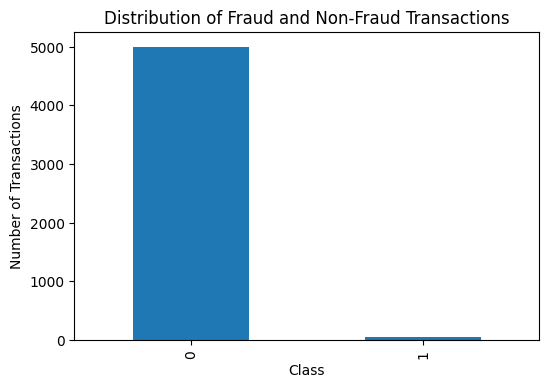

In [10]:
plt.figure(figsize=(6,4))

df['Class'].value_counts().plot(
    kind='bar'
)

plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Fraud and Non-Fraud Transactions")

plt.show()

### Percentage Distribution of Fraud

In [11]:
fraud_percentage = (
    df['Class']
    .value_counts(normalize=True)
    *100
)

fraud_percentage

Class
0    99.009901
1     0.990099
Name: proportion, dtype: float64

### Transaction Amount Distribution

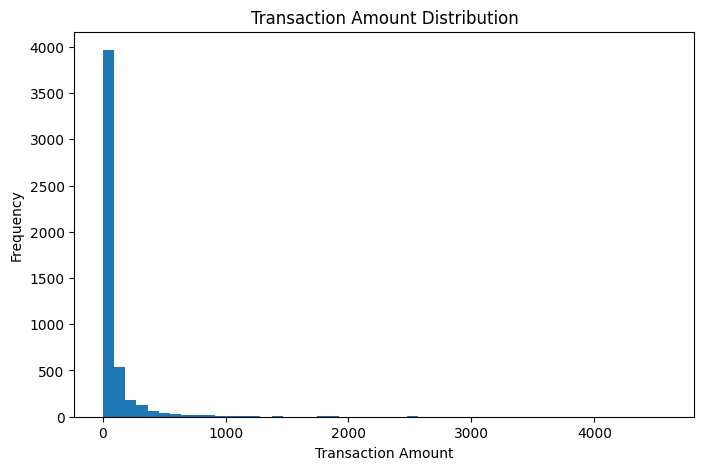

In [12]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Amount'],
    bins=50
)

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Transaction Amount Distribution")

plt.show()

### Check Correlation with Fraud Class

In [13]:
# Correlation analysis

correlation = df.corr()

class_corr = (
    correlation['Class']
    .sort_values(ascending=False)
)

class_corr

Class     1.000000
V11       0.360431
V4        0.323109
V2        0.210337
V19       0.109045
V8        0.106072
V27       0.093865
V21       0.093397
V20       0.027319
Amount    0.012039
V22       0.010831
V28       0.002254
V26      -0.003848
V24      -0.004709
V15      -0.010237
V13      -0.010786
V25      -0.013536
V23      -0.014009
ID       -0.026022
V6       -0.123232
V9       -0.221299
V5       -0.248258
V1       -0.254561
V18      -0.292037
V7       -0.428502
V3       -0.429185
V16      -0.447464
V10      -0.458619
V12      -0.554434
V14      -0.590921
V17      -0.609336
Name: Class, dtype: float64

### Top Features Related to Fraud

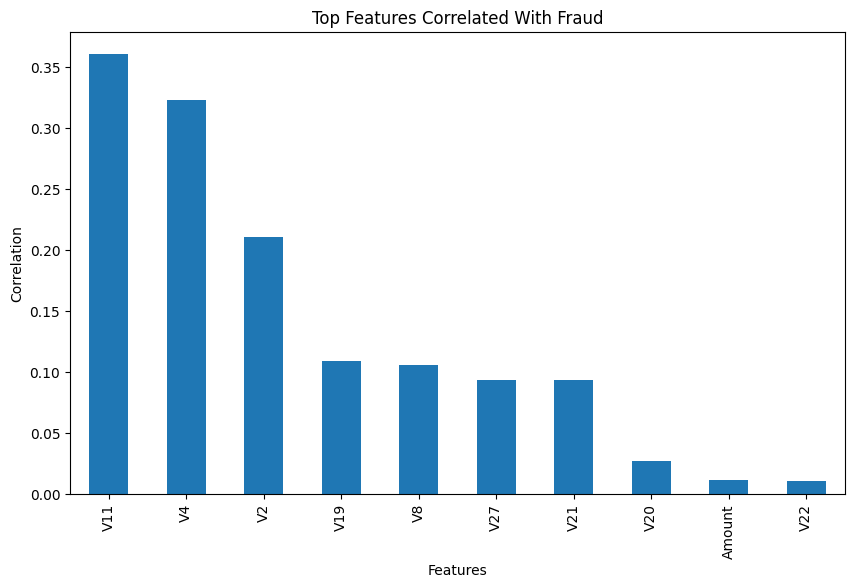

In [14]:
plt.figure(figsize=(10,6))

class_corr.drop('Class').head(10).plot(
    kind='bar'
)

plt.title(
    "Top Features Correlated With Fraud"
)

plt.xlabel("Features")
plt.ylabel("Correlation")

plt.show()

### Define Features and Target

In [15]:
# Independent variables

X = df.drop(
    ['Class','ID'],
    axis=1
)


# Target variable

y = df['Class']


print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (5050, 29)
Target Shape: (5050,)


### Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print(
    "Training Data:",
    X_train.shape
)

print(
    "Testing Data:",
    X_test.shape
)

Training Data: (4040, 29)
Testing Data: (1010, 29)


### Feature Scaling

In [17]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)


print("Feature scaling completed")

Feature scaling completed


### Handle Class Imbalance Using SMOTE

In [18]:
smote = SMOTE(
    random_state=42
)


X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)


print(
    "Before SMOTE:",
    y_train.value_counts()
)


print(
    "After SMOTE:",
    y_train_balanced.value_counts()
)

Before SMOTE: Class
0    4000
1      40
Name: count, dtype: int64
After SMOTE: Class
0    4000
1    4000
Name: count, dtype: int64


### Create Model Evaluation Function

In [19]:
def evaluate_model(model_name, model, X_test, y_test):

    prediction = model.predict(X_test)

    probability = model.predict_proba(X_test)[:,1]


    accuracy = accuracy_score(
        y_test,
        prediction
    )

    precision = precision_score(
        y_test,
        prediction
    )

    recall = recall_score(
        y_test,
        prediction
    )

    f1 = f1_score(
        y_test,
        prediction
    )

    auc = roc_auc_score(
        y_test,
        probability
    )


    results = pd.DataFrame({
        "Model":[model_name],
        "Accuracy":[accuracy],
        "Precision":[precision],
        "Recall":[recall],
        "F1 Score":[f1],
        "ROC-AUC":[auc]
    })


    return results

### Logistic Regression

In [20]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


lr_model.fit(
    X_train_balanced,
    y_train_balanced
)


lr_results = evaluate_model(
    "Logistic Regression",
    lr_model,
    X_test_scaled,
    y_test
)


lr_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.99604,0.714286,1.0,0.833333,0.9996


### Decision Tree

In [21]:
dt_model = DecisionTreeClassifier(
    random_state=42
)


dt_model.fit(
    X_train_balanced,
    y_train_balanced
)


dt_results = evaluate_model(
    "Decision Tree",
    dt_model,
    X_test_scaled,
    y_test
)


dt_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.994059,0.625,1.0,0.769231,0.997


### Random Forest Baseline

In [22]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


rf_model.fit(
    X_train_balanced,
    y_train_balanced
)


rf_results = evaluate_model(
    "Random Forest",
    rf_model,
    X_test_scaled,
    y_test
)


rf_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.99901,0.909091,1.0,0.952381,0.99985


### Gradient Boosting

In [23]:
gb_model = GradientBoostingClassifier(
    random_state=42
)


gb_model.fit(
    X_train_balanced,
    y_train_balanced
)


gb_results = evaluate_model(
    "Gradient Boosting",
    gb_model,
    X_test_scaled,
    y_test
)


gb_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.99505,0.666667,1.0,0.8,0.9994


### XGBoost Model

In [24]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)


xgb_model.fit(
    X_train_balanced,
    y_train_balanced
)


xgb_results = evaluate_model(
    "XGBoost",
    xgb_model,
    X_test_scaled,
    y_test
)


xgb_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,1.0,1.0,1.0,1.0,1.0


### Combine Model Results

In [25]:
results = pd.concat(
    [
        lr_results,
        dt_results,
        rf_results,
        gb_results,
        xgb_results
    ],
    ignore_index=True
)


results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.996040,0.714286,1.0,0.833333,0.99960
1,Decision Tree,0.994059,0.625000,1.0,0.769231,0.99700
2,Random Forest,0.999010,0.909091,1.0,0.952381,0.99985
3,Gradient Boosting,0.995050,0.666667,1.0,0.800000,0.99940
4,XGBoost,1.000000,1.000000,1.0,1.000000,1.00000


### Compare Models Graphically

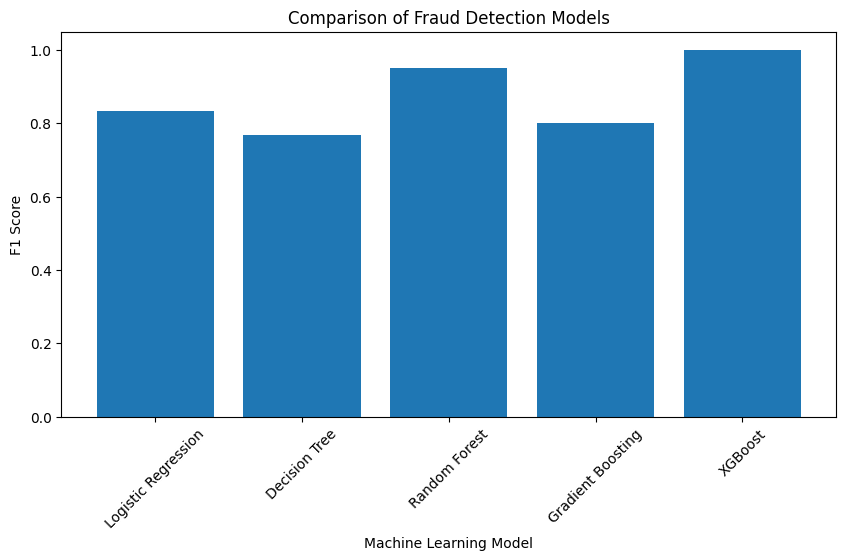

In [26]:
plt.figure(figsize=(10,5))

plt.bar(
    results['Model'],
    results['F1 Score']
)


plt.xlabel("Machine Learning Model")
plt.ylabel("F1 Score")

plt.title(
    "Comparison of Fraud Detection Models"
)

plt.xticks(rotation=45)

plt.show()

### Confusion Matrix for Best Model

In [27]:
best_model = xgb_model


prediction = best_model.predict(
    X_test_scaled
)


cm = confusion_matrix(
    y_test,
    prediction
)


cm

array([[1000,    0],
       [   0,   10]], dtype=int64)

### Display Classification Report

In [28]:
print(
    classification_report(
        y_test,
        prediction
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00        10

    accuracy                           1.00      1010
   macro avg       1.00      1.00      1.00      1010
weighted avg       1.00      1.00      1.00      1010



### ROC Curve Comparison

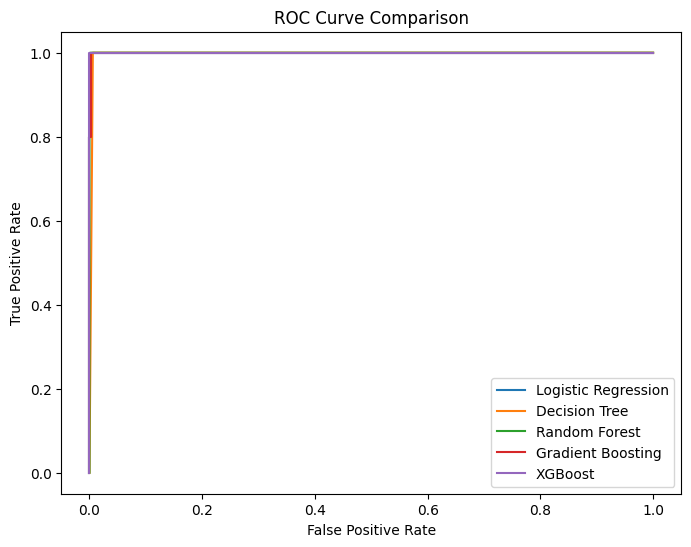

In [29]:
models = {
    "Logistic Regression":lr_model,
    "Decision Tree":dt_model,
    "Random Forest":rf_model,
    "Gradient Boosting":gb_model,
    "XGBoost":xgb_model
}


plt.figure(figsize=(8,6))


for name,model in models.items():

    probabilities = model.predict_proba(
        X_test_scaled
    )[:,1]


    fpr,tpr,threshold = roc_curve(
        y_test,
        probabilities
    )


    plt.plot(
        fpr,
        tpr,
        label=name
    )


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve Comparison"
)

plt.legend()

plt.show()

### Feature Importance of XGBoost

In [30]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":
    xgb_model.feature_importances_

})


importance = importance.sort_values(
    by="Importance",
    ascending=False
)


importance.head(10)

,Feature,Importance
13,V14,0.700689
22,V23,0.057268
3,V4,0.039398
11,V12,0.024218
24,V25,0.019108
0,V1,0.016788
28,Amount,0.015420
10,V11,0.011623
20,V21,0.011459
2,V3,0.010266


### Feature Importance Plot

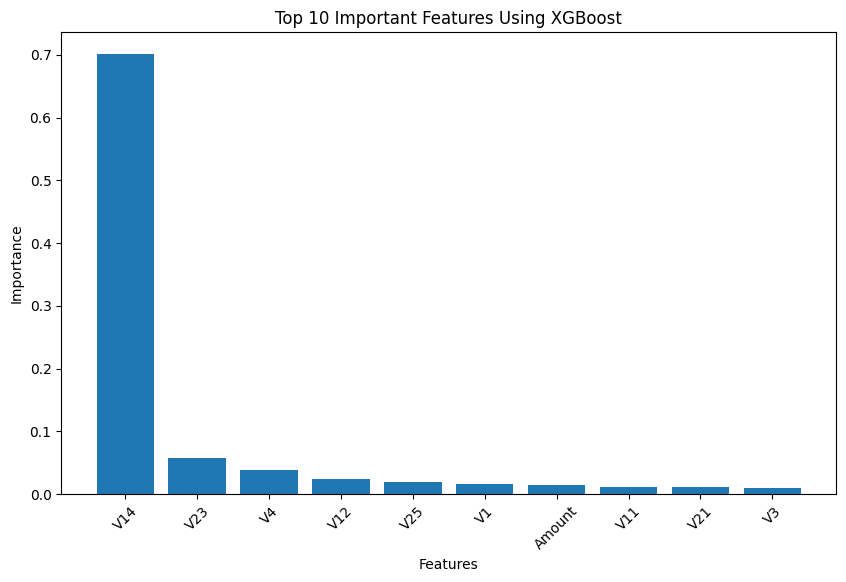

In [31]:
plt.figure(figsize=(10,6))

plt.bar(
    importance['Feature'].head(10),
    importance['Importance'].head(10)
)


plt.xlabel(
    "Features"
)

plt.ylabel(
    "Importance"
)


plt.title(
    "Top 10 Important Features Using XGBoost"
)


plt.xticks(rotation=45)

plt.show()

### Final Results

In [32]:
results.to_csv(
    "fraud_detection_model_results.csv",
    index=False
)

print(
    "Results saved successfully"
)

Results saved successfully
